# **Analítica Computacional para la toma de Decisiones Avanzada – Taller 6 202610**

## Clasificación con Redes Neuronales- Iris

Tome como base el modelo de redes neuronales presentado en el cuaderno de la clase
para predecir la especie de una planta con base en los datos Iris.

---

Daniel Benavides - 202220428 - <d.benavidess@uniandes.edu.co>

Juanita Cortés - 202222129 - <jv.cortesv1@uniandes.edu.co>

In [98]:
import tensorflow as tf
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



In [99]:
iris = load_iris()

print(iris.data[0:3,])
print(iris.target[0:3,])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
[0 0 0]


1. Seleccione una de las especies y cree una variable de respuesta binaria que sea 1 cuando la observación corresponda a la especie seleccionada y 0 de lo contrario. 

In [100]:

y = iris.target
X = iris.data
# crear variable binaria
y_binary = (y == 0).astype(int)

print("Número de observaciones:", len(y_binary))
print("Número de setosa:", sum(y_binary))
print("Número de no setosa:", len(y_binary) - sum(y_binary))

Número de observaciones: 150
Número de setosa: 50
Número de no setosa: 100


2. Crear un modelo usando Keras y TensorFlow para predecir si la planta pertenece a la especie seleccionada

In [101]:
#separemos las variables
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42
)

#escalar las variables 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

2.1. Construir modelo base


In [102]:
model = tf.keras.Sequential([
    #primer capa y recibe 4 variables con base en Iris
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    #segunda capa
    tf.keras.layers.Dense(4, activation='relu'),
    #para que la salida sea binaria usamos una función sigmpode
    tf.keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\juani\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2.2 Compilar el modelo

In [103]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

3. Entrene este nuevo modelo, grafique el historial de p´erdida de entrenamiento y
validaci´on, calcule todas las m´etricas vistas en clase para evaluar modelos de
clasificaci´on (accuracy, precision, recall, etc) y comente sus resultados en su reporte.

In [104]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.6354 - loss: 0.7361 - val_accuracy: 0.7917 - val_loss: 0.6233
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6354 - loss: 0.7236 - val_accuracy: 0.7917 - val_loss: 0.6143
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6354 - loss: 0.7115 - val_accuracy: 0.7917 - val_loss: 0.6053
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6354 - loss: 0.6996 - val_accuracy: 0.7917 - val_loss: 0.5963
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6354 - loss: 0.6879 - val_accuracy: 0.7917 - val_loss: 0.5875
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6354 - loss: 0.6762 - val_accuracy: 0.7917 - val_loss: 0.5787
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6354 - loss: 0.6646 - val_accuracy: 0.7917 - val_loss: 0.5698
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6354 - loss: 0.6531 - val_accuracy: 0.7917 - val_loss: 0.5606

3.1. Graficar historial de pérdida

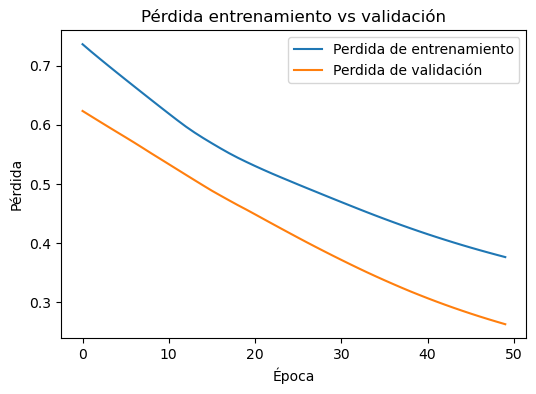

In [105]:

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Perdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Perdida de validación')

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida entrenamiento vs validación")
plt.legend()

plt.show()

3.2. Calcular métricas de clasificación

In [106]:
y_prob = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


In [107]:
y_pred = (y_prob > 0.5).astype(int)

In [108]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import numpy as np

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

auc = roc_auc_score(y_test, y_prob)

print("Matriz de confusión:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1:", f1)
print("ROC-AUC:", auc)


Matriz de confusión:
 [[20  0]
 [ 8  2]]
Accuracy: 0.7333333333333333
Precision: 1.0
Recall: 0.2
Specificity: 1.0
FPR: 0.0
FNR: 0.8
F1: 0.3333333333333333
ROC-AUC: 1.0


4. Modifique el n´umero de neuronas y capas (3 casos diferentes al modelo base), entrene
los modelos resultantes y compare las m´etricas obtenidas. Use siempre los mismos
datos de entrenamiento y prueba. Comente sus resultados en su reporte

In [109]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

def evaluar_modelo(model, X_train, y_train, X_test, y_test):

    history = model.fit(
        X_train, y_train,
        epochs=50,
        validation_split=0.2,
        verbose=0
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    resultados = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "specificity": tn / (tn + fp),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    }

    return resultados

In [110]:
#Modelo de red pequeña
#una sola capa oculta con 4 neuronas ( salida, sigmoide)
model_A = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

res_A = evaluar_modelo(model_A, X_train, y_train, X_test, y_test)

c:\Users\juani\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [111]:
#Modelo de red más profunda

model_B = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

res_B = evaluar_modelo(model_B, X_train, y_train, X_test, y_test)

c:\Users\juani\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
#Modelo de red más grande
model_C = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_C.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

res_C = evaluar_modelo(model_C, X_train, y_train, X_test, y_test)

c:\Users\juani\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [113]:

tabla = pd.DataFrame([
    {"modelo": "A", **res_A},
    {"modelo": "B", **res_B},
    {"modelo": "C", **res_C}
])

tabla

,modelo,accuracy,precision,recall,specificity,fpr,fnr,f1,auc
0,A,0.6,0.0,0.0,0.9,0.1,1.0,0.0,0.0
1,B,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
2,C,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0



## Clasificación con Redes Neuronales- Heart

Tome como base el modelo de redes neuronales presentado en el cuaderno de la clase
para predecir la especie de una planta con base en los datos Iris.


1. Crear modelo con subconjunto de variables

In [114]:
import pandas as pd

df = pd.read_csv("heart.csv")

features = [
    # continuas
    'age',        
    'trestbps',   
    'chol',       
    'thalach',     
    'oldpeak',     
    #categóricas    
    'sex',        
    'cp',          
    'fbs',         
    'exang',      
    'slope'       
]

X = df[features]
y = df['target']

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,#80% en entrenamiento y 20% en prueba<
    random_state=42,
    stratify=y
)

In [116]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Entrene este nuevo modelo (éste será nuestro modelo base), grafique el historial
de pérdida de entrenamiento y validaci´on, calcule todas las métricas vistas
en clase para evaluar modelos de clasificación (accuracy, precision, recall, etc) y
comente sus resultados en su reporte

In [117]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(len(features),)),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#Compilar
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Entrenar
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50


c:\Users\juani\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7358 - loss: 25.7924 - val_accuracy: 0.6939 - val_loss: 28.3135
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7358 - loss: 23.6821 - val_accuracy: 0.6939 - val_loss: 26.0475
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7358 - loss: 21.7276 - val_accuracy: 0.6939 - val_loss: 23.8766
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7358 - loss: 19.8533 - val_accuracy: 0.6939 - val_loss: 21.7868
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7358 - loss: 18.0656 - val_accuracy: 0.6939 - val_loss: 19.8679
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7358 - loss: 16.4015 - val_accuracy: 0.6939 - val_loss: 18.0850
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7358 - loss: 14.8378 - val_accuracy: 0.6939 - val_loss: 16.3751
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7358 - loss: 13.3471 - val_accuracy: 0.6939 - val_loss: 14.

2.2 Historial de pérdida

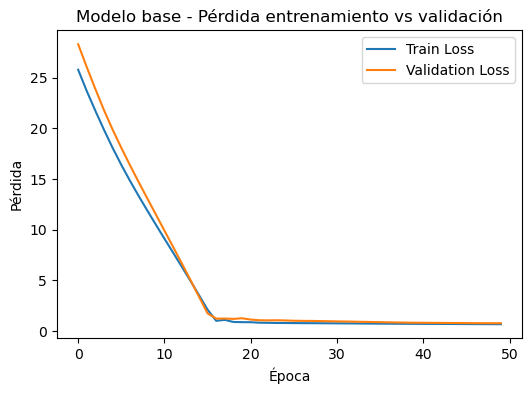

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Modelo base - Pérdida entrenamiento vs validación")
plt.legend()
plt.show()

2.3 Métricas

In [119]:
y_prob_base = model.predict(X_test)
y_pred_base = (y_prob_base > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


In [120]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve)
import numpy as np

cm = confusion_matrix(y_test, y_pred_base)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_base)
precision = precision_score(y_test, y_pred_base)
recall = recall_score(y_test, y_pred_base)          # TPR
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
f1 = f1_score(y_test, y_pred_base)
auc = roc_auc_score(y_test, y_prob_base)

print("Matriz de confusión:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1-score:", f1)
print("ROC-AUC:", auc)

Matriz de confusión:
 [[36  8]
 [12  5]]
Accuracy: 0.6721311475409836
Precision: 0.38461538461538464
Recall: 0.29411764705882354
Specificity: 0.8181818181818182
FPR: 0.18181818181818182
FNR: 0.7058823529411765
F1-score: 0.3333333333333333
ROC-AUC: 0.5989304812834224


3. Modifique el optimizador empleado (2 casos diferentes al modelo base), entrene
los modelos resultantes y compare las m´etricas obtenidas. Use siempre los mismos
datos de entrenamiento y prueba. Comente sus resultados en su reporte

3. Cambiar optimizador (2 casos)

4. Cambiar learning rate (3 casos)